[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/josterri/predicting-the-next-words-notebooks/blob/main/ch10_workbook.ipynb)

# Subword tokens by byte-pair encoding

Byte-pair encoding builds a vocabulary by counting: it merges the most frequent
pair of adjacent symbols in a text into one new symbol, and repeats, each merge
adding one token. Merges learned from Pride and Prejudice split the novel's
frequent words into few tokens and the words of other languages into many.

In [1]:
#@title Setup: run this cell first
import heapq
import os
import re
import unicodedata
import urllib.request
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
from IPython.display import Markdown, display

MIRROR_REF = "main"
TEXT_URL = f"https://raw.githubusercontent.com/josterri/predicting-the-next-words-notebooks/{MIRROR_REF}/data/pride_and_prejudice.txt"


def load_novel():
    """Pride and Prejudice as lowercase word tokens, one list per chapter."""
    if os.environ.get("PNW_TEXT"):
        text = open(os.environ["PNW_TEXT"], encoding="utf-8").read()
    else:
        try:
            text = urllib.request.urlopen(TEXT_URL).read().decode("utf-8")
        except OSError as e:
            raise RuntimeError(f"The text did not download from {TEXT_URL}: {e}. "
                               "Run this cell again; every cell below needs it.") from None
    chapters = re.split(r"(?m)^CHAPTER [IVXLC]+\.$", text)[1:]
    return [re.findall(r"[a-z]+(?:'[a-z]+)*", c.lower().replace("’", "'")) for c in chapters]


plt.rcParams.update({"figure.figsize": (6, 3.5), "figure.autolayout": True, "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})
END, MAX_MERGES = "</w>", 5000
# Scripts written without spaces between words: a typed text in one is refused, as its words cannot be counted.
NO_SPACE = {"CJK", "HIRAGANA", "KATAKANA", "THAI", "LAO", "KHMER", "MYANMAR", "TIBETAN", "JAVANESE"}
# Articles 1 to 3 of the Universal Declaration of Human Rights, the article texts alone and
# the French Article 2 without its paragraph numbers, read on 2026-10-01 from
# https://www.un.org/en/about-us/universal-declaration-of-human-rights (English),
# https://www.ohchr.org/sites/default/files/UDHR/Documents/UDHR_Translations/ger.pdf (German),
# https://www.un.org/fr/about-us/universal-declaration-of-human-rights (French).
# One line per language: the notebook's ceiling of 150 lines of code leaves no room to wrap them.
UDHR_EN = "All human beings are born free and equal in dignity and rights. They are endowed with reason and conscience and should act towards one another in a spirit of brotherhood. Everyone is entitled to all the rights and freedoms set forth in this Declaration, without distinction of any kind, such as race, colour, sex, language, religion, political or other opinion, national or social origin, property, birth or other status. Furthermore, no distinction shall be made on the basis of the political, jurisdictional or international status of the country or territory to which a person belongs, whether it be independent, trust, non-self-governing or under any other limitation of sovereignty. Everyone has the right to life, liberty and security of person."
UDHR_DE = "Alle Menschen sind frei und gleich an Würde und Rechten geboren. Sie sind mit Vernunft und Gewissen begabt und sollen einander im Geiste der Brüderlichkeit begegnen. Jeder hat Anspruch auf alle in dieser Erklärung verkündeten Rechte und Freiheiten, ohne irgendeinen Unterschied, etwa nach Rasse, Hautfarbe, Geschlecht, Sprache, Religion, politischer oder sonstiger Anschauung, nationaler oder sozialer Herkunft, Vermögen, Geburt oder sonstigem Stand. Des weiteren darf kein Unterschied gemacht werden auf Grund der politischen, rechtlichen oder internationalen Stellung des Landes oder Gebietes, dem eine Person angehört, gleichgültig ob dieses unabhängig ist, unter Treuhandschaft steht, keine Selbstregierung besitzt oder sonst in seiner Souveränität eingeschränkt ist. Jeder hat das Recht auf Leben, Freiheit und Sicherheit der Person."
UDHR_FR = "Tous les êtres humains naissent libres et égaux en dignité et en droits. Ils sont doués de raison et de conscience et doivent agir les uns envers les autres dans un esprit de fraternité. Chacun peut se prévaloir de tous les droits et de toutes les libertés proclamés dans la présente Déclaration, sans distinction aucune, notamment de race, de couleur, de sexe, de langue, de religion, d'opinion politique ou de toute autre opinion, d'origine nationale ou sociale, de fortune, de naissance ou de toute autre situation. De plus, il ne sera fait aucune distinction fondée sur le statut politique, juridique ou international du pays ou du territoire dont une personne est ressortissante, que ce pays ou territoire soit indépendant, sous tutelle, non autonome ou soumis à une limitation quelconque de souveraineté. Tout individu a droit à la vie, à la liberté et à la sûreté de sa personne."


# A setting a cell refuses: Colab prints the one sentence, without the stack.
class Refused(Exception):
    _render_traceback_ = lambda self: [str(self)]  # noqa: E731


def need(ok, name, value, rule):
    if not ok: raise Refused(f"{name} is {value!r}, of type {type(value).__name__}: {rule}.")  # noqa: E701
    return value


def whole(n, low, name="MERGES"):
    return need(type(n) is int and low <= n <= MAX_MERGES, name, n, f"it must be a whole number from {low} to {MAX_MERGES:,}")


# A typed text's words: runs of letters and combining marks (Unicode categories L and M), an
# apostrophe allowed between two of them. Accented letters, ß and Devanagari's vowel signs stay in
# their word; the loader's split of the novel keeps a to z and the apostrophe alone.
def split(text):
    kept = "".join(c if unicodedata.category(c)[0] in "LM" or c == "'" else " " for c in unicodedata.normalize("NFC", text).lower().replace("’", "'"))
    return re.findall(r"[^\s']+(?:'[^\s']+)*", kept)


# The words of a typed setting. A text in a script with no space between words is refused, and so
# is a WORD that is more than one word or longer than 60 letters and marks.
def words_of(text, name, one=False):
    w, t = split(str(text)), unicodedata.normalize("NFC", str(text)).lower().replace("’", "'").strip()
    scripts = sorted({unicodedata.name(c, "").replace("HALFWIDTH ", "").split(" ")[0] for c in t} & NO_SPACE)
    need(one or not scripts, name, text, f"it holds {' and '.join(scripts)} characters, a script written without spaces between words, so its words cannot be counted")
    rule = "it must be one word of at most 60 letters, an apostrophe allowed between two of them" if one else "it must hold a word of letters"
    need(isinstance(text, str) and w and (not one or w == [t] and len(t) <= 60), name, text, rule)
    return w


# The symbols s with every adjacent pair a b replaced by the one symbol ab, read left to right.
def join(s, pair):
    return re.sub(rf"(?<!\S){re.escape(' '.join(pair))}(?!\S)", "".join(pair), " ".join(s)).split()


# Pops stale heap entries and those of the pair skip; returns the top entry whose count is current.
def top(heap, count, skip=None):
    while heap and (heap[0][1] == skip or count[heap[0][1]] != -heap[0][0]):
        heapq.heappop(heap)
    return heap[0] if heap else (0, None)


# BPE on the novel's word types, each its letters and END, weighted by its count. Each merge takes
# the pair with the highest count, a tie going to the pair first in character order, and recounts
# only the words that hold it. Returns, per merge, the pair, its count and whether another pair had
# the same count, and each pair's rank in that order.
def learn(freq, n):
    segs, count, where, heap, merges = {w: [*w, END] for w in freq}, Counter(), defaultdict(set), [], []

    def tally(w, sign):
        for p in zip(segs[w], segs[w][1:]):
            count[p] += sign * freq[w]
            where[p].add(w)
            heapq.heappush(heap, (-count[p], p))
    for w in segs:
        tally(w, 1)
    while len(merges) < n and (best := top(heap, count))[0] < 0:
        merges.append((best[1], -best[0], top(heap, count, best[1])[0] == best[0]))
        for w in where.pop(best[1]):
            tally(w, -1)
            segs[w] = join(segs[w], best[1])
            tally(w, 1)
    return merges, {p: r for r, (p, _, _) in enumerate(merges)}


# A word's tokens at 0 merges and after each merge that changes them, as (merges, tokens):
# the learned merges apply in the order learned, the earliest the word holds first.
def history(word):
    out = [(0, [*word, END])]
    while (r := min((rank.get(p, MAX_MERGES) for p in zip(out[-1][1], out[-1][1][1:])), default=MAX_MERGES)) < MAX_MERGES:
        out.append((r + 1, join(out[-1][1], merges[r][0])))
    return out


def encode(word, k):
    return [s for m, s in history(word) if m <= k][-1]


def tokens_in(words, k):
    return sum(len(encode(w, k)) for w in words)


# Bars of the counts of the last 20 of the first n merges, "(tie)" where another pair had the same count.
def show_merges(n):
    rows = merges[max(0, whole(n, 1) - 20):n]
    fig, ax = plt.subplots()
    bars = ax.barh([f"{r:,}. {a} + {b}" + (" (tie)" if t else "") for r, ((a, b), _, t) in enumerate(rows, n - len(rows) + 1)], [c for _, c, _ in rows])
    ax.bar_label(bars, labels=[f"{c:,}" for _, c, _ in rows], fontsize=8, padding=2)
    ax.set(xlabel="count of the pair in the novel's words when merged", ylim=(len(rows) - 0.5, -0.5), xmargin=0.15)
    ax.xaxis.set(major_locator=plt.MaxNLocator(5, integer=True), major_formatter="{x:,.0f}")
    plt.show()


# Each text split into tokens after k merges, as a table, and its tokens per word as a stacked
# bar: tokens in the learned vocabulary, then characters outside the loader's alphabet, a token each.
def show_texts(texts, k):
    ws = {n: words_of(t, n) for n, t in texts.items()}
    display(Markdown("| | words | tokens | split into tokens |\n| --- | ---: | ---: | --- |\n" + "\n".join(
        f"| {n} | {len(w)} | {tokens_in(w, k)} | `{' '.join('·'.join(encode(x, k)) for x in w)}` |" for n, w in ws.items())))
    # Characters outside the loader's alphabet, a to z and the apostrophe: no merge holds one, so each is a token.
    tot, out = [tokens_in(w, k) / len(w) for w in ws.values()], [sum(c not in alphabet for x in w for c in x) / len(w) for w in ws.values()]
    fig, ax = plt.subplots()
    ax.barh(list(ws), [t - o for t, o in zip(tot, out)], label="tokens in the learned vocabulary")
    bars = ax.barh(list(ws), out, left=[t - o for t, o in zip(tot, out)], color="w", edgecolor="C0", hatch="///", label="letters and marks outside a to z")
    ax.bar_label(bars, labels=[f"{t:.2f}" for t in tot], padding=3)
    ax.set(xlabel=f"tokens per word after {k:,} merges", ylim=(len(ws) - 0.5, -0.5), xlim=(0, 1.2 * max(tot)))
    ax.legend(loc="lower left", bbox_to_anchor=(0, 1), ncol=2, frameon=False)
    plt.show()


chapters = load_novel()
freq = Counter(w for c in chapters for w in c)
alphabet = set("".join(freq))
merges, rank = learn(freq, MAX_MERGES)
passages = {"English": split(UDHR_EN), "German": split(UDHR_DE), "French": split(UDHR_FR)}
display(Markdown(f"{len(chapters)} chapters, {sum(freq.values()):,} words and {len(freq):,} word types as the loader splits them, into the {len(alphabet)} characters a to z and the apostrophe, which with `</w>` make the base vocabulary; "
                 f"{len(merges):,} merges learned. The first three articles of the declaration: " + ", ".join(f"{len(w)} words in {lang}" for lang, w in passages.items()) + "."))

61 chapters, 122,174 words and 6,314 word types as the loader splits them, into the 27 characters a to z and the apostrophe, which with `</w>` make the base vocabulary; 5,000 merges learned. The first three articles of the declaration: 121 words in English, 113 words in German, 148 words in French.

## 1. The first merge joins a letter to the end of a word

The loader splits the novel into words of the letters a to z and the
apostrophe, and each word starts as those characters followed by the
end-of-word marker `</w>`. BPE counts every adjacent pair of symbols, `</w>`
included, each word weighted by its count, and merges the pair with the
highest count; a tie goes to the pair first in character order. Run the cell,
then set `MERGES` to 1000 and run it again. Which pair does BPE merge first,
and how many of the merges up to merge `MERGES`, the last 20 at most, join a
symbol to `</w>`?

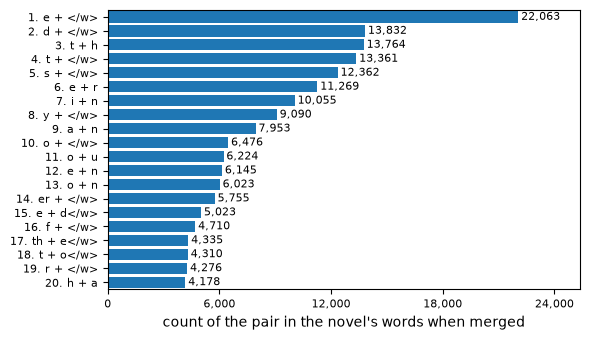

In [2]:
MERGES = 20
show_merges(MERGES)

### Solution

In [3]:
rows, ((a, b), c, _) = merges[max(0, whole(MERGES, 1) - 20):MERGES], merges[0]
display(Markdown(f"The first merge joins `{a}` and `{b}`, a pair the novel's words hold {c:,} times. Among the merges numbered {MERGES - len(rows) + 1:,} to {MERGES:,}, "
                 f"the number joining a symbol to `</w>` is {sum(y == END for (_, y), _, _ in rows)}, the number joining one to a token ending in `</w>` is {sum(y.endswith(END) and y != END for (_, y), _, _ in rows)}, "
                 f"and the number at which another pair had the same count, so that character order chose, is {sum(r[2] for r in rows)}."))

The first merge joins `e` and `</w>`, a pair the novel's words hold 22,063 times. Among the merges numbered 1 to 20, the number joining a symbol to `</w>` is 9, the number joining one to a token ending in `</w>` is 3, and the number at which another pair had the same count, so that character order chose, is 0.

## 2. A frequent name becomes one token

A word is split by applying the learned merges in the order they were
learned. Run the cell, then put a word of your own into `WORD`, for example one
the novel never uses. Into which tokens does `WORD` split after 1,000 merges,
and after how many merges is it one token?

In [4]:
WORD = "pemberley"
rows = history(words_of(WORD, "WORD", one=True)[0])
display(Markdown("| after merge | tokens |\n| ---: | --- |\n"
                 + "\n".join(f"| {m:,} | `{' '.join(s)}` |" for m, s in rows)))

| after merge | tokens |
| ---: | --- |
| 0 | `p e m b e r l e y </w>` |
| 6 | `p e m b er l e y </w>` |
| 8 | `p e m b er l e y</w>` |
| 54 | `p e m b er le y</w>` |
| 241 | `p e m b er ley</w>` |
| 328 | `p em b er ley</w>` |
| 573 | `p em ber ley</w>` |
| 955 | `p em berley</w>` |
| 957 | `p emberley</w>` |
| 962 | `pemberley</w>` |

### Solution

In [5]:
w = words_of(WORD, "WORD", one=True)[0]
h, toks, new = history(w), encode(w, 1000), "".join(sorted(set(w) - alphabet))
last = next((f"it is one token from merge {m:,} on" for m, s in h if len(s) == 1), f"after {MAX_MERGES:,} merges its number of tokens is {len(h[-1][1])}")
display(Markdown(f"After 1,000 merges \"{w}\" splits as `{' · '.join(toks)}`, and {last}. Its count among the novel's words as the loader splits them is {freq[w]:,}. Of the merges that joined its symbols, "
                 f"{len(h) - 1} in all, another pair had the same count at {sum(merges[m - 1][2] for m, _ in h[1:])}. Characters outside the loader's alphabet, a to z and the apostrophe: {new or 'none'}."))

After 1,000 merges "pemberley" splits as `pemberley</w>`, and it is one token from merge 962 on. Its count among the novel's words as the loader splits them is 53. Of the merges that joined its symbols, 9 in all, another pair had the same count at 4. Characters outside the loader's alphabet, a to z and the apostrophe: none.

## 3. Tokens per word in German and in English

`SENTENCE` holds a German sentence and `ENGLISH` its English translation, each
split into tokens by the first 1,000 merges learned from the novel. Run the
cell, then put a German sentence of your own into `SENTENCE` and its
translation into `ENGLISH`. How many tokens per word does each sentence need,
and how many of the German tokens are letters outside a to z and the
apostrophe, the alphabet BPE learned from?

| | words | tokens | split into tokens |
| --- | ---: | ---: | --- |
| SENTENCE | 11 | 30 | `al·le</w> men·s·ch·en</w> sin·d</w> fre·i</w> un·d</w> g·le·i·ch</w> an</w> w·ü·r·de</w> un·d</w> re·ch·ten</w> ge·b·or·en</w>` |
| ENGLISH | 12 | 23 | `all</w> hu·man</w> be·ings</w> are</w> b·or·n</w> fre·e</w> and</w> equ·al</w> in</w> di·g·n·ity</w> and</w> ri·gh·ts</w>` |

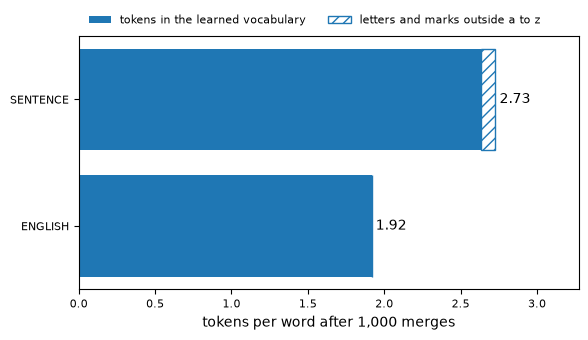

In [6]:
SENTENCE = "Alle Menschen sind frei und gleich an Würde und Rechten geboren."
ENGLISH = "All human beings are born free and equal in dignity and rights."
show_texts({"SENTENCE": SENTENCE, "ENGLISH": ENGLISH}, 1000)

### Solution

In [7]:
de, en = words_of(SENTENCE, "SENTENCE"), words_of(ENGLISH, "ENGLISH")
t_de, t_en, used = tokens_in(de, 1000), tokens_in(en, 1000), {m for x in de + en for m, _ in history(x)[1:] if m <= 1000}
out = [sum(c not in alphabet for x in w for c in x) for w in (de, en)]
display(Markdown(f"After 1,000 merges SENTENCE needs {t_de / len(de):.2f} tokens per word and ENGLISH {t_en / len(en):.2f}: {t_de} tokens for {len(de)} words "
                 f"against {t_en} for {len(en)}. Characters outside the loader's alphabet, a to z and the apostrophe, make {out[0]} of SENTENCE's tokens and "
                 f"{out[1]} of ENGLISH's. Of the {len(used)} merges applied, another pair had the same count at {sum(merges[m - 1][2] for m in used)}, and character order chose."))

After 1,000 merges SENTENCE needs 2.73 tokens per word and ENGLISH 1.92: 30 tokens for 11 words against 23 for 12. Characters outside the loader's alphabet, a to z and the apostrophe, make 1 of SENTENCE's tokens and 0 of ENGLISH's. Of the 46 merges applied, another pair had the same count at 4, and character order chose.

## Appendix. Tokens per word against the number of merges

BPE starts each word w as its letters followed by `</w>`, so the base
vocabulary V₀ is the alphabet of the novel's words as the loader splits them,
a to z and the apostrophe, and `</w>`. Each merge counts every adjacent pair of
symbols over the word types, each weighted by its frequency f(w),

count(a, b) = Σ f(w) · n(w, a b), summed over the word types w,

where n(w, a b) is the number of times b follows a among the symbols of w, and
replaces every adjacent a b by the new symbol ab for the pair

(a, b) = argmax count(a, b) over all adjacent pairs,

a tie going to the pair first in character order. Taking the last pair in
character order leaves the first merges unchanged and changes a small share of
the first 1,000; later, many pairs stand tied at small counts, the rule decides
which of them enter the vocabulary, and the values at 5,000 merges depend on it.
K merges give a vocabulary of |V₀| + K tokens. A new word is split by applying
the merges in the order learned. A letter outside the alphabet, ü or é among
them, is outside the vocabulary: no merge holds it, and each one costs a token
of its own. At K = 0 a word of n letters is n + 1 tokens.

A text of N words split into T tokens has T / N tokens per word, its
fertility. Two translations of one text compare by the ratio of their tokens,
the premium T(German) / T(English).

Tokens per word from 100 to 5,000 merges learned from the novel, for the first
three articles of the Universal Declaration of Human Rights in English, German
and French:

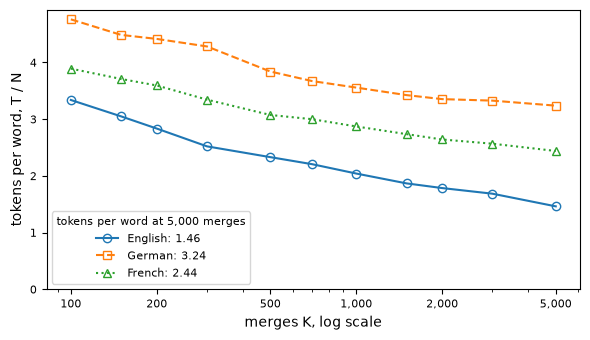

In [8]:
grid = [100, 150, 200, 300, 500, 700, 1000, 1500, 2000, 3000, 5000]
fig, ax = plt.subplots()
for (name, w), style in zip(passages.items(), ("o-", "s--", "^:")):
    y = [tokens_in(w, k) / len(w) for k in grid]
    ax.plot(grid, y, style, markerfacecolor="none", label=f"{name}: {y[-1]:.2f}")
ax.set(xscale="log", xlabel="merges K, log scale", ylabel="tokens per word, T / N", ylim=(0, None))
ax.set_xticks(grid[::2], labels=["100", "200", "500", "1,000", "2,000", "5,000"])
ax.legend(loc="lower left", title=f"tokens per word at {MAX_MERGES:,} merges", title_fontsize=8)
plt.show()

**Exercise.** Set `K` to 0, then 100, 1000 and 5000, and rerun the cell each
time. How many tokens per word does each language need, and does the premium
of German over English grow or shrink as the merges grow?

In [9]:
K = 1000

t = {lang: tokens_in(w, whole(K, 0, "K")) for lang, w in passages.items()}
for lang, w in passages.items():
    print(f"{lang}: {t[lang] / len(w):.2f} tokens per word, premium {t[lang] / t['English']:.2f}")

English: 2.04 tokens per word, premium 1.00
German: 3.56 tokens per word, premium 1.63
French: 2.87 tokens per word, premium 1.72


### Solution

In [10]:
ks = [0, 100, 200, 500, 1000, 2000, 5000]
pw = {k: {lang: tokens_in(w, k) / len(w) for lang, w in passages.items()} for k in ks}
prem = {k: tokens_in(passages["German"], k) / tokens_in(passages["English"], k) for k in ks}
print("\n".join(f"{k:5,} merges: " + ", ".join(f"{x} {v:.2f}" for x, v in pw[k].items()) + f"; German premium {prem[k]:.2f}" for k in ks))
en, seen = [pw[k]["English"] for k in (100, 1000, 5000)], {x: f"{sum(v in freq for v in w)} of {len(w)}" for x, w in passages.items()}
display(Markdown(f"English falls from {en[0]:.2f} tokens per word at 100 merges to {en[1]:.2f} at 1,000, a drop of {en[0] - en[1]:.2f} over the tenfold step, and to {en[2]:.2f} at 5,000, "
                 f"a drop of {en[1] - en[2]:.2f} over the fivefold step. Before any merge German needs {pw[0]['German']:.2f} tokens per word against English's {pw[0]['English']:.2f}, a premium "
                 f"of {prem[0]:.2f} counting letters and end-of-word markers and {sum(map(len, passages['German'])) / sum(map(len, passages['English'])):.2f} counting letters alone; it is {prem[100]:.2f} at 100 merges and {prem[5000]:.2f} at 5,000, and rises between {sum(prem[b] > prem[a] for a, b in zip(ks[1:], ks[2:]))} "
                 f"of the {len(ks) - 2} pairs of neighbouring values drawn from 100 on. The novel's words as the loader splits them hold {seen['English']} English, {seen['German']} German and "
                 f"{seen['French']} French words of the passages. At {sum(t for _, _, t in merges):,} of the {MAX_MERGES:,} merges another pair had the same count; the last joins a pair held {merges[-1][1]} times."))

    0 merges: English 6.04, German 7.24, French 5.85; German premium 1.12
  100 merges: English 3.34, German 4.76, French 3.89; German premium 1.33
  200 merges: English 2.83, German 4.42, French 3.59; German premium 1.45
  500 merges: English 2.33, German 3.84, French 3.07; German premium 1.54
1,000 merges: English 2.04, German 3.56, French 2.87; German premium 1.63
2,000 merges: English 1.79, German 3.35, French 2.64; German premium 1.75
5,000 merges: English 1.46, German 3.24, French 2.44; German premium 2.07


English falls from 3.34 tokens per word at 100 merges to 2.04 at 1,000, a drop of 1.30 over the tenfold step, and to 1.46 at 5,000, a drop of 0.58 over the fivefold step. Before any merge German needs 7.24 tokens per word against English's 6.04, a premium of 1.12 counting letters and end-of-word markers and 1.16 counting letters alone; it is 1.33 at 100 merges and 2.07 at 5,000, and rises between 5 of the 5 pairs of neighbouring values drawn from 100 on. The novel's words as the loader splits them hold 100 of 121 English, 8 of 113 German and 30 of 148 French words of the passages. At 4,525 of the 5,000 merges another pair had the same count; the last joins a pair held 3 times.